# UdaciMed | Notebook 2: Architecture Optimization

Welcome back to UdaciMed's optimization pipeline! In this notebook, you will implement hardware-aware architectural modifications to achieve our critical memory reduction goals.

### Recap: **Optimization challenge**

From [Notebook 1](01_baseline_analysis.ipynb), we identified that our ResNet-18 baseline model faces **memory, computation, speed, and throughput challenges**:

- **Target FLOP reduction**: >80% _(to achieve <0.4 GFLOPs per sample)_
- **Target memory usage**: <100MB 
- **Target throughput**: >2,000 samples/sec 
- **Target latency**: <3ms

while keeping **model sensitivity** >98%.

You have outlined an optimization strategy as part of your baseline model analysis, it is now time to develop the architectural optimizations.

### **Architecture optimization strategy**

You will implement and evaluate at least **3 architecture optimization techniques** out of the ones previously analyzed, as listed below:

1. Interpolation Removal
2. Depthwise Separable Convolution
3. Grouped Convolutions
4. Inverted Residual Blocks
5. Low-Rank Factorization
6. Channel Optimization
7. Parameter Sharing

Test all implemented techniques separately, and collect results. Then, decide the final optimization strategy (not all need to be enabled!) for the next phase.

---

Through this notebook, you will:
- **Implement >=3 optimization techniques** with modular toggles
- **Compare performance impacts** across memory, latency, FLOPs, and throughput
- **Validate clinical safety** by monitoring sensitivity metrics
- **Create an optimized model** with the most efficient architectural optimization settings

**Let's transform our baseline into a production-ready, memory-efficient diagnostic model!**

## Step 1: Setup and load baseline results

First, let's set up the environment and load our baseline model with analysis from Notebook 1.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
import random
import copy
import matplotlib.pyplot as plt
from pprint import pprint
from torchsummary import summary
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds
)
from utils.profiling import (
    PerformanceProfiler,
    measure_time
)
from utils.visualization import (
    plot_batch_size_comparison,
    plot_performance_profile,
    plot_operation_breakdown
)
from utils.architecture_optimization import (
    apply_interpolation_removal_optimization,
    apply_depthwise_separable_optimization,
    apply_grouped_convolution_optimization,
    apply_inverted_residual_optimization,
    apply_lowrank_factorization,
    apply_channel_optimization,
    apply_parameter_sharing,
    create_optimized_model
)

# Set the device for pytorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: CUDA not available - optimization profiling will be limited")

print("Architecture optimization environment ready!")

Using device: cpu
Architecture optimization environment ready!


In [3]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


> **Why deterministic mode matters**
>
> Small variations in random initialization can make it difficult to assess the true impact of optimization techniques. Deterministic mode ensures that performance differences reflect architectural changes, not random variation.

In [4]:
# Updated targets based on baseline analysis findings
OPTIMIZATION_TARGETS = {
    'memory_mb': 100,                   # MB 
    'throughput_samples_sec': 2000,     # samples/sec
    'latency_ms': 3,                    # ms 
    'sensitivity_percent': 98,          # %
    'flop_reduction_percent': 80        # % 
}

print("Optimization targets for production deployment:")
for metric, target in OPTIMIZATION_TARGETS.items():
    print(f"   {metric.replace('_', ' ').title()}: {target}")

Optimization targets for production deployment:
   Memory Mb: 100
   Throughput Samples Sec: 2000
   Latency Ms: 3
   Sensitivity Percent: 98
   Flop Reduction Percent: 80


In [5]:
# Load baseline results from Notebook 1
try:
    with open('../results/baseline_results.pkl', 'rb') as f:
        baseline_results = pickle.load(f)
    
    print("Loaded baseline results from Notebook 1:")
    print(f"   Model: {baseline_results['model_name']}")
    print(f"   Parameters: {baseline_results['total_parameters']:,}")
    print(f"   Model Size: {baseline_results['model_size_mb']:.1f} MB")
    print(f"   Memory Usage: {baseline_results['memory']['peak_memory_mb']:.1f} MB")
    print(f"   Inference Time: {baseline_results['timing']['single_sample_ms']:.2f} ms")
    print(f"   Throughput: {baseline_results['timing']['batch_throughput_samples_per_sec']:.0f} samples/sec")
    print(f"   Clinical Sensitivity: {baseline_results['eval_results'][0.7]['recall']:.1%}")
    
except FileNotFoundError:
    print("ERROR: Baseline results not found. Please run Notebook 1 first.")
    raise

Loaded baseline results from Notebook 1:
   Model: ResNet-18 Baseline
   Parameters: 11,177,538
   Model Size: 42.6 MB
   Memory Usage: 1484.0 MB
   Inference Time: 33.10 ms
   Throughput: 38 samples/sec
   Clinical Sensitivity: 99.2%


In [6]:
# Recreate baseline model and load the trained weights
baseline_config = baseline_results['config']
baseline_model = create_baseline_model(
    num_classes=baseline_config['num_classes'], 
    input_size=baseline_config['image_size'], 
    pretrained=False
)

try:
    baseline_model.load_state_dict(torch.load('../results/best_baseline_model.pth', map_location=device))
    baseline_model = baseline_model.to(device)
    baseline_model.eval()
    print("Loaded trained baseline model successfully")
except FileNotFoundError:
    print("WARNING: Trained model weights not found. Using randomly initialized model.")
    baseline_model = baseline_model.to(device)

Loaded trained baseline model successfully


In [7]:
# Load test dataset for evaluation
test_loader = load_pneumoniamnist(
    split="test", 
    download=True, 
    size=baseline_config['image_size'], 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.15 if baseline_config['subset_size'] is not None else None
)

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(test_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"Test data loaded: {sample_images.shape} batch for profiling")
print(f"   Batch memory footprint: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")
print(f"   Class distribution: {sample_labels.sum().item()}/{len(sample_labels)} positive cases")

Using downloaded and verified file: /home/architect/.medmnist/pneumoniamnist_64.npz


Test data loaded: torch.Size([32, 3, 64, 64]) batch for profiling
   Batch memory footprint: 1.5 MB
   Class distribution: 23/32 positive cases


## Step 2: Configure optimization strategy

Define which optimizations to apply. 

Each technique can be independently enabled/disabled, allowing you to understand individual contributions and find the optimal combination for your use case.

In [8]:
# Configure the optimization strategy by setting each technique to True/False
# Strategy from Notebook 1: interpolation removal is the dominant win (~12x less
# convolution work), depthwise separable convolutions attack the remaining conv
# FLOPs, and channel optimization adds hardware-level gains at zero accuracy risk.
# The remaining techniques were analyzed but not selected: grouped conv overlaps
# with depthwise separable (a weaker version of the same idea), low-rank
# factorization has no qualifying linear layers in ResNet-18, and inverted
# residuals / parameter sharing add accuracy risk for modest projected gains.

OPTIMIZATION_CONFIG = {
    # Enable/disable optimizations
    'interpolation_removal': True,          # biggest single win: process 64x64 natively
    'grouped_conv': False,                  # superseded by depthwise separable
    'depthwise_separable': True,            # ~8-9x fewer conv parameters and FLOPs
    'channel_optimization': True,           # channels_last + in-place ReLU, no accuracy risk
    'inverted_residuals': False,            # full block redesign, not needed to hit targets
    'lowrank_factorization': False,         # no linear layer large enough to qualify
    'parameter_sharing': False,             # accuracy risk outweighs memory benefit

    # Execution parameters for training and inference
    'memory_format': torch.channels_last,   # NHWC pairs well with depthwise convs
    'use_amp': torch.cuda.is_available()    # AMP needs CUDA; enabled automatically on the T4
}

print("Optimization configuration:")
for technique, enabled in OPTIMIZATION_CONFIG.items():
    if isinstance(enabled, bool):
        status = "ENABLED" if enabled else "DISABLED"
        print(f"   {technique.replace('_', ' ').title()}: {status}")


Optimization configuration:
   Interpolation Removal: ENABLED
   Grouped Conv: DISABLED
   Depthwise Separable: ENABLED
   Channel Optimization: ENABLED
   Inverted Residuals: DISABLED
   Lowrank Factorization: DISABLED
   Parameter Sharing: DISABLED
   Use Amp: DISABLED


> **Tips for optimization strategy**: 
> 
> 1. Start with one technique at a time to understand individual contributions. 
> 2. Experiment with different optimization parameters by updating the parameters set in the optimization function calls in `create_optimized_model()` (less refactoring), or update `create_optimized_model()` to take parameters from _`OPTIMIZATION_CONFIG`_ and set them directly in the config (more seamless experimentation).

## Step 3: Apply architectural optimizations

Now let's create the optimized model by applying your selected techniques.

**IMPORTANT**: This is where most of your *TODOs* lie, as you need to implement optimization methods and pipeline in `utils/architecture_optimization.ipynb`. You can find hints in the functions' definitions within the utility script.

In [9]:
# Build the optimized model using the techniques implemented in
# `utils/architecture_optimization.py` (applied in dependency order there)

print("Creating optimized model with selected techniques...")

optimized_model = create_optimized_model(baseline_model, OPTIMIZATION_CONFIG)
optimized_model = optimized_model.to(device)

print("\nOptimized model created successfully!")
print(f"   Device: {next(optimized_model.parameters()).device}")


Creating optimized model with selected techniques...
Starting clinical model optimization pipeline...
   Applying interpolation removal optimization...


Applying native resolution optimization (64x64)...
INTERPOLATION REMOVAL completed.
   Applying depthwise separable optimization...
Applying depthwise separable convolution optimization...
DEPTHWISE SEPARABLE completed: Successfully applied to layers with 16 replacements
   Applying channel optimization optimization...
Applying channel-level hardware optimizations...
   In-place ReLU: 0 layers converted
   Memory format: channels_last (remember to convert inputs too)
CHANNEL OPTIMIZATION completed
Applied optimizations in order: interpolation_removal → depthwise_separable → channel_optimization

Optimized model created successfully!
   Device: cpu


In [10]:
# Review new model architecture
summary(optimized_model, input_size=(3, baseline_config['image_size'], baseline_config["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]             576
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]           4,096
DepthwiseSeparableConv2d-9           [-1, 64, 16, 16]               0
      BatchNorm2d-10           [-1, 64, 16, 16]             128
             ReLU-11           [-1, 64, 16, 16]               0
           Conv2d-12           [-1, 64, 16, 16]             576
      BatchNorm2d-13           [-1, 64, 16, 16]             128
             ReLU-14           [-

> **How have the optimizations changed the expected model size in MB?**
> 
> Optimizations can either increase or decrease different memory components for the model. Use the above summary as a sanity check for your optimizations' implementations.

In [11]:
# Analyze the new memory footprint
def count_unique_parameters(model):
    """Count actual unique parameter tensors (shared params counted once)"""
    unique_params = {}
    total_params = 0
    
    for name, param in model.named_parameters():
        param_id = id(param)
        if param_id not in unique_params:
            unique_params[param_id] = {
                'tensor': param,
                'shape': param.shape,
                'elements': param.numel(),
                'first_seen': name,
                'shared_with': []
            }
        else:
            unique_params[param_id]['shared_with'].append(name)
    
    total_unique_elements = sum(info['elements'] for info in unique_params.values())
    
    return total_unique_elements, len(unique_params), unique_params

baseline_unique, baseline_objects, _ = count_unique_parameters(baseline_model)
optimized_unique, optimized_objects, optimized_params_details = count_unique_parameters(optimized_model)

baseline_state_size = sum(p.numel() for p in baseline_model.parameters())
optimized_state_size = sum(p.numel() for p in optimized_model.parameters())

print(f"Baseline model:")
print(f"   State dict size: {baseline_state_size:,} elements")
print(f"   Unique parameters: {baseline_unique:,} elements")

print(f"Optimized model:")
print(f"   State dict size: {optimized_state_size:,} elements")  # Remove the "(same as baseline)" text!
print(f"   Unique parameters: {optimized_unique:,} elements")

reduction = ((baseline_state_size - optimized_state_size) / baseline_state_size * 100)
print(f"Total parameter reduction: {reduction:.1f}%")

n_shared_params = sum([len(param_details['shared_with']) for param_id, param_details in optimized_params_details.items()])
print(f"# Shared parameters: {n_shared_params}")

Baseline model:
   State dict size: 11,177,538 elements
   Unique parameters: 11,177,538 elements
Optimized model:
   State dict size: 1,449,986 elements
   Unique parameters: 1,449,986 elements
Total parameter reduction: 87.0%
# Shared parameters: 0


> **Do you see the expected parameter reduction?**
> 
> The analysis above showcases both parameter reduction and parameter sharing (if applied). Optimizing model parameters directly contributes to memory savings, but remember: activation memory during inference often dominates, especially with larger input sizes!

## Step 4: Initialize optimized model via transfer learning

While we have changed the architecture, we can still transfer knowledge from the trained baseline model to our optimized architecture for any matching layers.

Preserving learned features where possible reduces retraining time and maintains clinical performance.

In [12]:
# Transfer compatible weights from baseline to optimized model
# This preserves learned features where possible, reducing retraining time

def transfer_compatible_weights(source_model, target_model):
    """
    Transfer weights from source model to target model where layer shapes match.
    This preserves learned representations in unmodified layers.
    """
    source_dict = dict(source_model.named_parameters())
    target_dict = dict(target_model.named_parameters())

    transferred_layers = []
    skipped_layers = []

    # A parameter can be reused when the same name still exists and its shape
    # is unchanged; replaced layers (new module types or different geometry)
    # either miss from the source or come back with a different shape.
    with torch.no_grad():
        for name, target_param in target_dict.items():
            source_param = source_dict.get(name)
            if source_param is not None and source_param.shape == target_param.shape:
                target_param.copy_(source_param)
                transferred_layers.append(name)
            else:
                skipped_layers.append(name)

    return transferred_layers, skipped_layers

print("Transferring compatible weights from baseline to optimized model...")
transferred, skipped = transfer_compatible_weights(baseline_model, optimized_model)

print(f"\nTransferred {len(transferred)} compatible layers")
print(f"Skipped {len(skipped)} modified/new layers")


Transferring compatible weights from baseline to optimized model...

Transferred 46 compatible layers
Skipped 64 modified/new layers


## Step 5: Train/Fine-tune the optimized model

The optimized model needs training to learn the weights of new layers defined by the architectural changes.

If the number of new layers is low, keep in mind that lower learning rates can help preserve transferred knowledge while adapting to architectural changes for faster convergence.

In [13]:
# Load training data for fine-tuning the optimized model
# We need both training and validation data to fine-tune the model

train_loader = load_pneumoniamnist(
    split="train", 
    download=True, 
    size=baseline_config['image_size'], 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.7 if baseline_config['subset_size'] is not None else None
)

val_loader = load_pneumoniamnist(
    split="val", 
    download=True, 
    size=baseline_config['image_size'], 
    batch_size=baseline_config['batch_size'],
    subset_size=baseline_config['subset_size'] * 0.15 if baseline_config['subset_size'] is not None else None
)

print(f"Training data loaded:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Image size: {baseline_config['image_size']}x{baseline_config['image_size']}")

Using downloaded and verified file: /home/architect/.medmnist/pneumoniamnist_64.npz


Using downloaded and verified file: /home/architect/.medmnist/pneumoniamnist_64.npz
Training data loaded:
   Training batches: 148
   Validation batches: 17
   Image size: 64x64


In [14]:
# Configure training parameters
# The depthwise separable stages are freshly initialized, so this is closer to
# a retrain than a fine-tune: enough epochs to converge, a moderate learning
# rate, and patience high enough to survive the noisy early epochs.

FINE_TUNING_CONFIG = {
    'num_epochs': 15,            # fresh conv stages need real training time
    'learning_rate': 0.0005,     # higher than a pure fine-tune since most convs are new
    'lr_step_size': 5,           # decay by 10x every 5 epochs
    'weight_decay': 1e-4,        # same regularization as the baseline run
    'patience': 5,               # early stopping once validation accuracy stalls
    'memory_format': OPTIMIZATION_CONFIG['memory_format']  # match the model's layout
}

print("Fine-tuning configuration:")
for key, value in FINE_TUNING_CONFIG.items():
    print(f"   {key}: {value}")


Fine-tuning configuration:
   num_epochs: 15
   learning_rate: 0.0005
   lr_step_size: 5
   weight_decay: 0.0001
   patience: 5
   memory_format: torch.channels_last


Fine-tuning optimized model...
Starting baseline model training for pneumonia detection...
   Config: 15 epochs, lr=0.0005, wd=0.0001


Epoch 1/15 [Train]:   0%|                                                   | 0/148 [00:00<?, ?it/s]

Epoch 1/15 [Train]:   0%|                            | 0/148 [00:00<?, ?it/s, Loss=1.808, Acc=59.4%]

Epoch 1/15 [Train]:   1%|▏                   | 1/148 [00:00<00:40,  3.62it/s, Loss=1.808, Acc=59.4%]

Epoch 1/15 [Train]:   1%|▏                   | 1/148 [00:00<00:40,  3.62it/s, Loss=0.897, Acc=65.6%]

...

Epoch 15/15 [Val]:  76%|████████████████     | 13/17 [00:00<00:00, 29.49it/s, Loss=0.183, Acc=96.9%]

Epoch 15/15 [Val]:  76%|████████████████     | 13/17 [00:00<00:00, 29.49it/s, Loss=0.188, Acc=96.9%]

Epoch 15/15 [Val]:  76%|████████████████     | 13/17 [00:00<00:00, 29.49it/s, Loss=0.188, Acc=96.9%]

Epoch 15/15 [Val]: 100%|█████████████████████| 17/17 [00:00<00:00, 31.82it/s, Loss=0.188, Acc=96.9%]

   Epoch 15: Train Acc  99.5% | Val Acc  96.9% | Train Loss 0.0241 | Val Loss 0.1550 | LR 0.000005
     Early stopping triggered after 15 epochs (patience: 5)
Training completed! Best validation accuracy: 97.14%


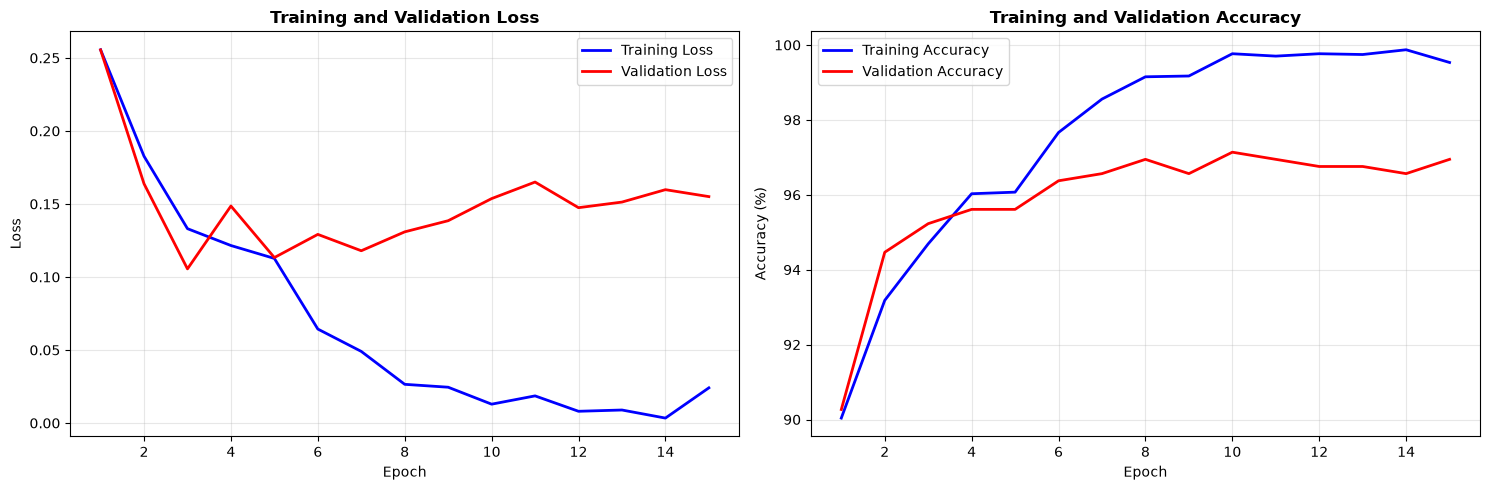


Training Summary:
   Best Validation Accuracy: 97.1%
   Total Epochs: 15
   Final Training Accuracy: 99.5%
   Final Validation Accuracy: 96.9%


In [15]:
# Train/Fine-tune the optimized model
print("Fine-tuning optimized model...")
optimized_model, fine_tuning_history = train_baseline_model(
    optimized_model, train_loader, val_loader, device, FINE_TUNING_CONFIG, save_path="../results/optimized_model.pth",
)

# Plot fine-tuning progress
plot_training_history(fine_tuning_history)

> **_Indicators of training success_**:
> 
> - **Validation accuracy** should recover to within 1-2% of baseline (target: >98%)
> - **Training should converge quickly** (2-5 epochs), especially with transferred weights
> - **Loss curves should be smooth** without significant overfitting
> 
> If training struggles, consider: reducing learning rate, increasing epochs, or simplifying optimizations.

## Step 6: Evaluate clinical performance

Critical step: validate that optimizations maintain clinical safety standards.

In [16]:
# Evaluate clinical performance of the optimized model
print("Evaluating clinical performance of optimized model...")

# Sweep the screening-to-diagnostic range of operating points
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
eval_results = evaluate_with_multiple_thresholds(optimized_model, test_loader, device, thresholds)

# Sensitivity >98% is a hard clinical requirement; among the thresholds that
# clear it, take the highest one so specificity (false-positive load on
# radiologists) stays as good as possible.
qualifying = [t for t, m in eval_results.items() if m['recall'] >= 0.98]
optimized_classification_threshold = max(qualifying) if qualifying else min(thresholds)
print(f"\nSelected classification threshold: {optimized_classification_threshold}")
optimized_metrics = eval_results[optimized_classification_threshold]


Evaluating clinical performance of optimized model...

Evaluating with threshold 0.3:


Clinical Evaluation Results (threshold: 0.300):
   Accuracy:  86.5%
   Precision: 83.0% (PPV - Positive Predictive Value)
   Recall:    98.7% (Sensitivity)
   F1 Score:  90.2%
   AUC-ROC:   0.945

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     155
   False Positives (Normal misclassified):            79
   False Negatives (Pneumonia missed):                 5
   True Positives (Pneumonia correctly detected):   385

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.7% (detects 98.7% of pneumonia cases)
   Specificity (True Negative Rate):     66.2% (correctly identifies 66.2% of normal cases)
   PPV (Positive Predictive Value):      83.0% (when model predicts pneumonia, it's correct 83.0% of time)
   NPV (Negative Predictive Value):      96.9% (when model predicts normal, it's correct 96.9% of time)

Clinical Significance:
   False Negative Rate: 1.3% (missed pneumonia cases - critical for patient safety)
   False Positive 

Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  87.5%
   Precision: 84.1% (PPV - Positive Predictive Value)
   Recall:    98.7% (Sensitivity)
   F1 Score:  90.8%
   AUC-ROC:   0.945

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     161
   False Positives (Normal misclassified):            73
   False Negatives (Pneumonia missed):                 5
   True Positives (Pneumonia correctly detected):   385

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.7% (detects 98.7% of pneumonia cases)
   Specificity (True Negative Rate):     68.8% (correctly identifies 68.8% of normal cases)
   PPV (Positive Predictive Value):      84.1% (when model predicts pneumonia, it's correct 84.1% of time)
   NPV (Negative Predictive Value):      97.0% (when model predicts normal, it's correct 97.0% of time)

Clinical Significance:
   False Negative Rate: 1.3% (missed pneumonia cases - critical for patient safety)
   False Positive 

Clinical Evaluation Results (threshold: 0.500):
   Accuracy:  87.7%
   Precision: 84.4% (PPV - Positive Predictive Value)
   Recall:    98.5% (Sensitivity)
   F1 Score:  90.9%
   AUC-ROC:   0.945

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     163
   False Positives (Normal misclassified):            71
   False Negatives (Pneumonia missed):                 6
   True Positives (Pneumonia correctly detected):   384

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.5% (detects 98.5% of pneumonia cases)
   Specificity (True Negative Rate):     69.7% (correctly identifies 69.7% of normal cases)
   PPV (Positive Predictive Value):      84.4% (when model predicts pneumonia, it's correct 84.4% of time)
   NPV (Negative Predictive Value):      96.4% (when model predicts normal, it's correct 96.4% of time)

Clinical Significance:
   False Negative Rate: 1.5% (missed pneumonia cases - critical for patient safety)
   False Positive 

Clinical Evaluation Results (threshold: 0.600):
   Accuracy:  87.7%
   Precision: 84.5% (PPV - Positive Predictive Value)
   Recall:    98.2% (Sensitivity)
   F1 Score:  90.9%
   AUC-ROC:   0.945

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     164
   False Positives (Normal misclassified):            70
   False Negatives (Pneumonia missed):                 7
   True Positives (Pneumonia correctly detected):   383

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.2% (detects 98.2% of pneumonia cases)
   Specificity (True Negative Rate):     70.1% (correctly identifies 70.1% of normal cases)
   PPV (Positive Predictive Value):      84.5% (when model predicts pneumonia, it's correct 84.5% of time)
   NPV (Negative Predictive Value):      95.9% (when model predicts normal, it's correct 95.9% of time)

Clinical Significance:
   False Negative Rate: 1.8% (missed pneumonia cases - critical for patient safety)
   False Positive 

Clinical Evaluation Results (threshold: 0.700):
   Accuracy:  87.7%
   Precision: 84.5% (PPV - Positive Predictive Value)
   Recall:    98.2% (Sensitivity)
   F1 Score:  90.9%
   AUC-ROC:   0.945

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     164
   False Positives (Normal misclassified):            70
   False Negatives (Pneumonia missed):                 7
   True Positives (Pneumonia correctly detected):   383

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     98.2% (detects 98.2% of pneumonia cases)
   Specificity (True Negative Rate):     70.1% (correctly identifies 70.1% of normal cases)
   PPV (Positive Predictive Value):      84.5% (when model predicts pneumonia, it's correct 84.5% of time)
   NPV (Negative Predictive Value):      95.9% (when model predicts normal, it's correct 95.9% of time)

Clinical Significance:
   False Negative Rate: 1.8% (missed pneumonia cases - critical for patient safety)
   False Positive 

In [17]:
# Compare optimized model performance against baseline

# Compare against the baseline at its screening threshold from Notebook 1
# (0.4 was the operating point that kept sensitivity highest there)
baseline_classification_thr = 0.4
baseline_metrics = baseline_results['eval_results'][baseline_classification_thr]

print("BASELINE vs OPTIMIZED PERFORMANCE COMPARISON:")
print(f"\n   Sensitivity (Recall):")
print(f"     Baseline:  {baseline_metrics['recall']:.1%}")
print(f"     Optimized: {optimized_metrics['recall']:.1%}")
sensitivity_change = (optimized_metrics['recall'] - baseline_metrics['recall']) * 100
print(f"     Change:    {sensitivity_change:+.1f} percentage points")

print(f"\n   Overall Accuracy:")
print(f"     Baseline:  {baseline_metrics['accuracy']:.1%}")
print(f"     Optimized: {optimized_metrics['accuracy']:.1%}")
accuracy_change = (optimized_metrics['accuracy'] - baseline_metrics['accuracy']) * 100
print(f"     Change:    {accuracy_change:+.1f} percentage points")

print(f"\n   AUC-ROC:")
print(f"     Baseline:  {baseline_metrics['auc']:.3f}")
print(f"     Optimized: {optimized_metrics['auc']:.3f}")
auc_change = optimized_metrics['auc'] - baseline_metrics['auc']
print(f"     Change:    {auc_change:+.3f}")

# Clinical safety assessment
print(f"\nCLINICAL SAFETY ASSESSMENT:")
optimized_sensitivity = optimized_metrics['recall']
if optimized_sensitivity >= 0.98:
    print(f"   SAFE: Sensitivity {optimized_sensitivity:.1%} meets clinical requirement (>98%)")
else:
    print(f"   WARNING: Sensitivity {optimized_sensitivity:.1%} below clinical requirement (>98%)")
    print(f"   RECOMMENDATION: Reduce optimization aggressiveness or retrain with sensitivity focus")

if abs(accuracy_change) <= 2.0:
    print(f"   ACCEPTABLE: Accuracy change {accuracy_change:+.1f}% within tolerance (±2%)")
else:
    print(f"   CAUTION: Accuracy change {accuracy_change:+.1f}% exceeds tolerance (±2%)")

BASELINE vs OPTIMIZED PERFORMANCE COMPARISON:

   Sensitivity (Recall):
     Baseline:  100.0%
     Optimized: 98.2%
     Change:    -1.8 percentage points

   Overall Accuracy:
     Baseline:  86.1%
     Optimized: 87.7%
     Change:    +1.6 percentage points

   AUC-ROC:
     Baseline:  0.969
     Optimized: 0.945
     Change:    -0.024

CLINICAL SAFETY ASSESSMENT:
   SAFE: Sensitivity 98.2% meets clinical requirement (>98%)
   ACCEPTABLE: Accuracy change +1.6% within tolerance (±2%)


## Step 7: Profile optimized model performance

Now let's measure the performance improvements from our optimizations.

Quantifying improvements validates that optimizations achieve their intended benefits and helps prioritize techniques for future projects.

In [18]:
# Profile the optimized model's inference performance
print("Profiling optimized model performance...")

# Initialize profiler
profiler = PerformanceProfiler(device=str(device), use_amp=OPTIMIZATION_CONFIG["use_amp"])

# Profile timing
optimized_timing = profiler.profile_inference_time(
    model=optimized_model,
    input_tensor=sample_images,
    num_runs=100,
    warmup_runs=10
)

print(f"\nTIMING RESULTS:")
print(f"   Single Sample Latency: {optimized_timing['single_sample_ms']:.2f} ms")
print(f"   Batch Throughput: {optimized_timing['batch_throughput_samples_per_sec']:.0f} samples/sec")
print(f"   Mean Inference Time: {optimized_timing['mean_ms']:.2f} ms")
print(f"   95th Percentile: {optimized_timing['p95_ms']:.2f} ms")

Profiling optimized model performance...



TIMING RESULTS:
   Single Sample Latency: 4.65 ms
   Batch Throughput: 1224 samples/sec
   Mean Inference Time: 4.65 ms
   95th Percentile: 5.28 ms


In [19]:
# Profile FLOPs of the optimized model
optimized_flops = profiler.profile_flops(
    model=optimized_model, 
    input_tensor=sample_images
)

if 'error' not in optimized_flops:
    print(f"\nFLOPs Results:")
    print(f"   Total: {optimized_flops['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {optimized_flops['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in optimized_flops and optimized_flops['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(optimized_flops['module_percentage'].items())[:5]:
            gflops = optimized_flops['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")
else:
    print(f"WARNING: FLOPs calculation failed: {optimized_flops['error']}")
    optimized_flops = {}

Unsupported operator aten::max_pool2d encountered 1 time(s)


Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 0.90 GFLOPs
   Per Sample: 0.03 GFLOPs

   Top Operations (by FLOPs):
     conv: 97.7% (0.88 GFLOPs)
     batch_norm: 2.3% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [20]:
# Profile memory usage of the optimized model
optimized_memory = profiler.profile_memory_usage(
    model=optimized_model,
    input_tensor=sample_images
)

if 'error' not in optimized_memory:
    print(f"\nMEMORY RESULTS:")
    print(f"   Peak Memory: {optimized_memory['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {optimized_memory['memory_increase_mb']:.1f} MB")

    if 'component_breakdown' in optimized_memory:
        components = optimized_memory['component_breakdown']
        print(f"\n   Memory Component Breakdown:")
        for component, usage in components.items():
            print(f"     {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    # Same CPU fallback as in Notebook 1: sample process RSS during the forward
    # pass and reconstruct the main components analytically
    print(f"CUDA memory profiling unavailable ({optimized_memory['error']}) - using CPU fallback")
    import gc
    import psutil

    process = psutil.Process()
    gc.collect()
    baseline_rss = process.memory_info().rss / 1024**2

    rss_samples = []
    activation_sizes_mb = []

    def _sample_memory(module, inputs, output):
        rss_samples.append(process.memory_info().rss / 1024**2)
        if torch.is_tensor(output):
            activation_sizes_mb.append(output.numel() * output.element_size() / 1024**2)

    hooks = [m.register_forward_hook(_sample_memory)
             for m in optimized_model.modules() if len(list(m.children())) == 0]
    with torch.no_grad():
        _ = optimized_model(sample_images)
    for h in hooks:
        h.remove()

    model_params_mb = sum(p.numel() * p.element_size() for p in optimized_model.parameters()) / 1024**2
    input_mb = sample_images.numel() * sample_images.element_size() / 1024**2

    optimized_memory = {
        'peak_memory_mb': max(rss_samples),
        'memory_increase_mb': max(rss_samples) - baseline_rss,
        'component_breakdown': {
            'model_parameters_mb': model_params_mb,
            'input_tensor_mb': input_mb,
            'activations_mb': sum(activation_sizes_mb),
            'largest_single_activation_mb': max(activation_sizes_mb),
        }
    }

    print(f"\nMEMORY RESULTS (CPU process-level fallback):")
    print(f"   Peak Process Memory: {optimized_memory['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase During Inference: {optimized_memory['memory_increase_mb']:.1f} MB")
    print(f"\n   Memory Component Breakdown (analytic):")
    for component, usage in optimized_memory['component_breakdown'].items():
        print(f"     {component.replace('_', ' ').title()}: {usage:.1f} MB")


CUDA memory profiling unavailable (GPU memory profiling only available with CUDA) - using CPU fallback



MEMORY RESULTS (CPU process-level fallback):
   Peak Process Memory: 717.4 MB
   Memory Increase During Inference: 0.0 MB

   Memory Component Breakdown (analytic):
     Model Parameters Mb: 5.5 MB
     Input Tensor Mb: 1.5 MB
     Activations Mb: 117.0 MB
     Largest Single Activation Mb: 8.0 MB


In [21]:
# Compare performance improvements against baseline to validate progress toward optimization targets

# Get baseline performance metrics
baseline_timing = baseline_results['timing']
baseline_memory = baseline_results['memory']
baseline_flops = baseline_results['flops']

print("PERFORMANCE IMPROVEMENT ANALYSIS:")

# Timing improvements
latency_improvement = baseline_timing['single_sample_ms'] / optimized_timing['single_sample_ms']
throughput_improvement = optimized_timing['batch_throughput_samples_per_sec'] / baseline_timing['batch_throughput_samples_per_sec']

print(f"\nSpeed Improvements:")
print(f"   Latency Speedup: {latency_improvement:.2f}x ({baseline_timing['single_sample_ms']:.2f}ms → {optimized_timing['single_sample_ms']:.2f}ms)")

# Memory improvements
if 'error' not in optimized_memory and 'error' not in baseline_memory:
    memory_reduction = (baseline_memory['peak_memory_mb'] - optimized_memory['peak_memory_mb']) / baseline_memory['peak_memory_mb'] * 100
    print(f"\n Memory Improvements:")
    print(f"   Memory Reduction: {memory_reduction:.1f}% ({baseline_memory['peak_memory_mb']:.1f}MB → {optimized_memory['peak_memory_mb']:.1f}MB)")
    
    # Check target progress
    if optimized_memory['peak_memory_mb'] <= OPTIMIZATION_TARGETS['memory_mb']:
        print(f"   TARGET ACHIEVED: {optimized_memory['peak_memory_mb']:.1f}MB ≤ {OPTIMIZATION_TARGETS['memory_mb']}MB")
    else:
        remaining_reduction = optimized_memory['peak_memory_mb'] - OPTIMIZATION_TARGETS['memory_mb']
        print(f"   TARGET PROGRESS: {remaining_reduction:.1f}MB reduction still needed")

# Throughput target check
print(f"\nThroughput Improvements:")
throughput_target_met = "TARGET ACHIEVED" if optimized_timing['batch_throughput_samples_per_sec'] >= OPTIMIZATION_TARGETS['throughput_samples_sec'] else "WARNING: TARGET IN PROGRESS"
print(f"   Throughput Gain: {throughput_improvement:.2f}x ({baseline_timing['batch_throughput_samples_per_sec']:.0f} → {optimized_timing['batch_throughput_samples_per_sec']:.0f} samples/sec)")
print(f"   Throughput Target: {throughput_target_met} ({optimized_timing['batch_throughput_samples_per_sec']:.0f} vs {OPTIMIZATION_TARGETS['throughput_samples_sec']} target)")

# Expected FLOP reduction (based on optimizations applied)
print(f"\nEstimated FLOP Reduction:")
new_ = optimized_flops['total_gflops']

flop_reduction_percent = (1 - (optimized_flops['total_gflops'] / baseline_flops['total_gflops'])) * 100
flop_target_met = "TARGET ACHIEVED" if flop_reduction_percent >= OPTIMIZATION_TARGETS['flop_reduction_percent'] else "WARNING: TARGET IN PROGRESS"
print(f"   FLOP Target: {flop_target_met} ({flop_reduction_percent:.2f} vs {OPTIMIZATION_TARGETS['flop_reduction_percent']})")


PERFORMANCE IMPROVEMENT ANALYSIS:

Speed Improvements:
   Latency Speedup: 7.11x (33.10ms → 4.65ms)

 Memory Improvements:
   Memory Reduction: 51.7% (1484.0MB → 717.4MB)
   TARGET PROGRESS: 617.4MB reduction still needed

Throughput Improvements:
   Throughput Gain: 32.60x (38 → 1224 samples/sec)
   Throughput Target: WARNING: TARGET IN PROGRESS (1224 vs 2000 target)

Estimated FLOP Reduction:
   FLOP Target: TARGET ACHIEVED (98.46 vs 80)


> **What if you are missing some targets, but you are confident that your optimization strategy and implementation are sound?**
> 
> If you almost hit deployment targets + maintain clinical safety, proceed to Notebook 3. Hardware deployment often closes the remaining gaps!
> If your clinical safety is slightly below threshold and you have already spent too much time trying to parameter tune, summarize what you'd do to hit this target with more time in the final markdown section here and proceed to Notebook 3.

   Profiling multiple batch sizes...


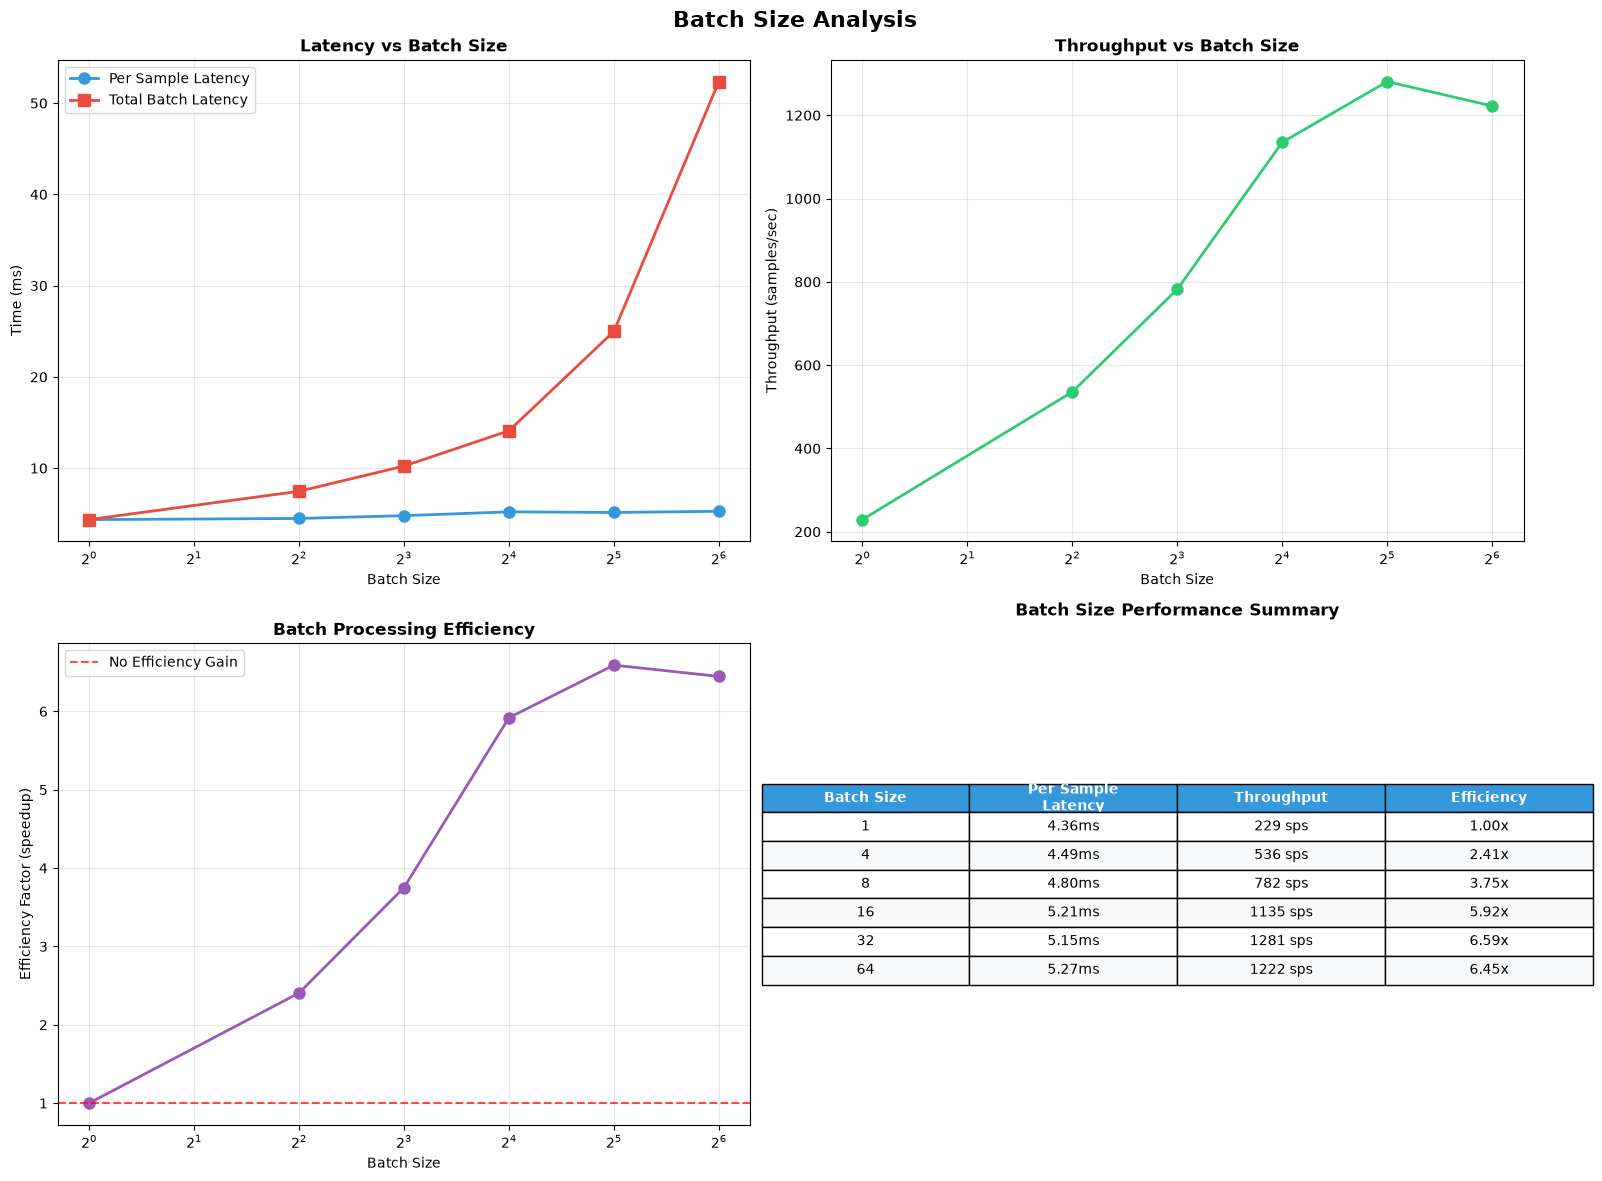

In [22]:
# Profile performance with different batch sizes
# Batch sizes a 16GB T4 handles comfortably for this model: 1 for real-time
# latency, powers of two up to 64 for throughput-oriented screening
batch_sizes = [1, 4, 8, 16, 32, 64]

print("   Profiling multiple batch sizes...")
batch_results = profiler.profile_multiple_batch_sizes(
    optimized_model, sample_images.shape, batch_sizes
)

# Visualize batch size analysis for deployment understanding
plot_batch_size_comparison(batch_results)

## Step 8: Visualize performance improvements

Create visual comparisons to understand the optimization impact.

Visual analysis helps identify bottlenecks, validate improvements, and communicate results to stakeholders who may not be familiar with raw performance metrics.

Generating performance visualizations...


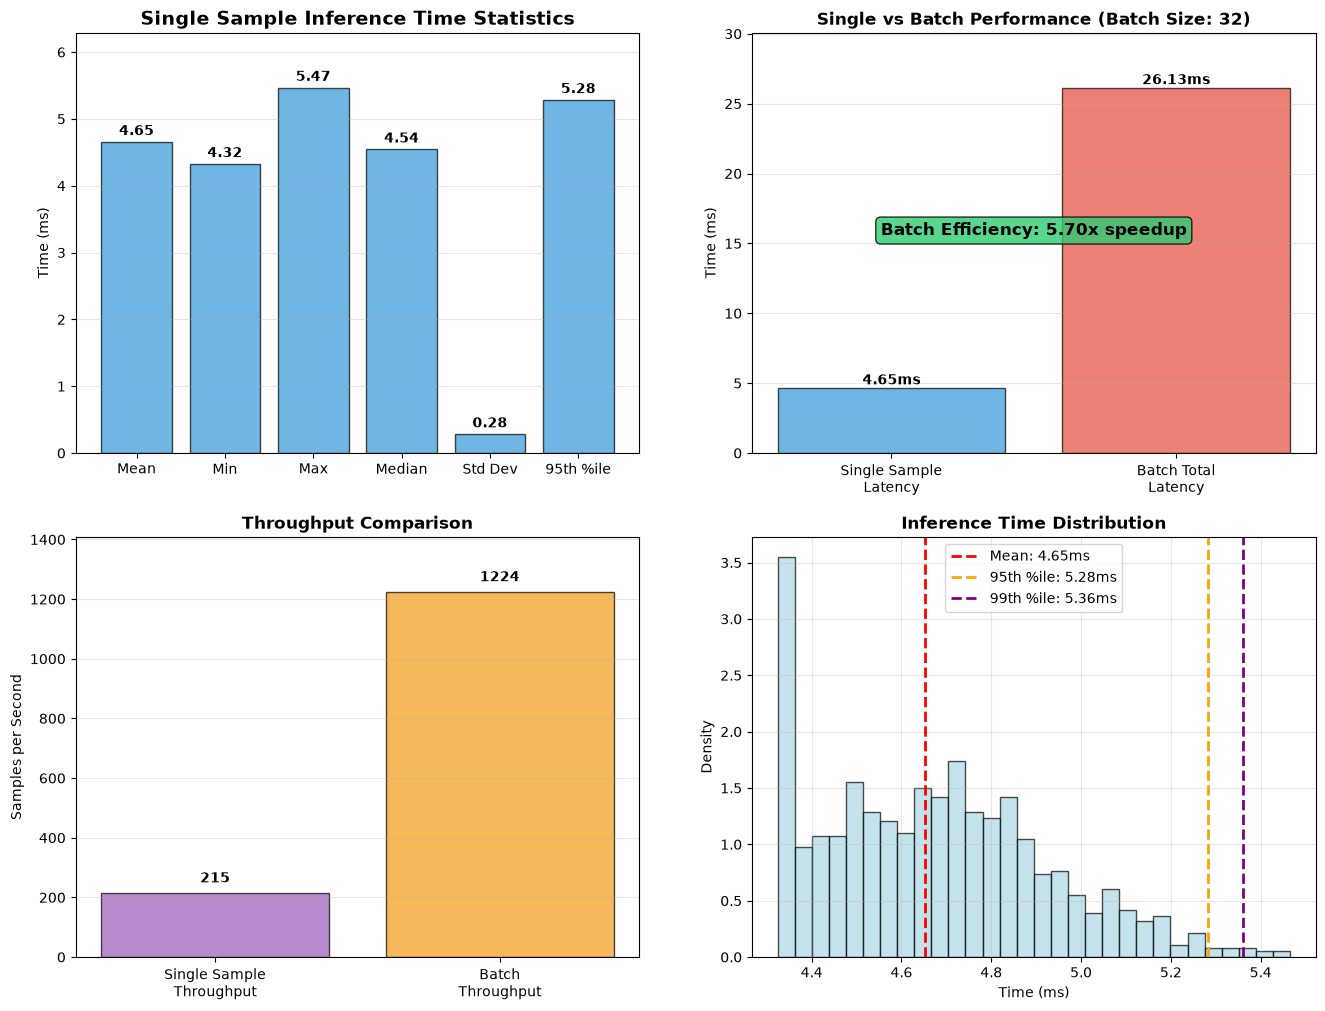

In [23]:
# Visualize the optimized model's performance profile, useful to understand where the performance gains come from

print("Generating performance visualizations...")
plot_performance_profile(optimized_timing)

Analyzing operation distribution changes...


STAGE:2026-08-05 01:12:09 1299184:1299184 ActivityProfilerController.cpp:314] Completed Stage: Warm Up


STAGE:2026-08-05 01:12:09 1299184:1299184 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-08-05 01:12:09 1299184:1299184 ActivityProfilerController.cpp:324] Completed Stage: Post Processing



Optimized Model Operation Breakdown:
   Convolution Ops: 76.6%
   Normalization Ops: 14.9%
   Other Ops: 3.0%
   Pooling Ops: 2.8%
   Activation Ops: 2.3%


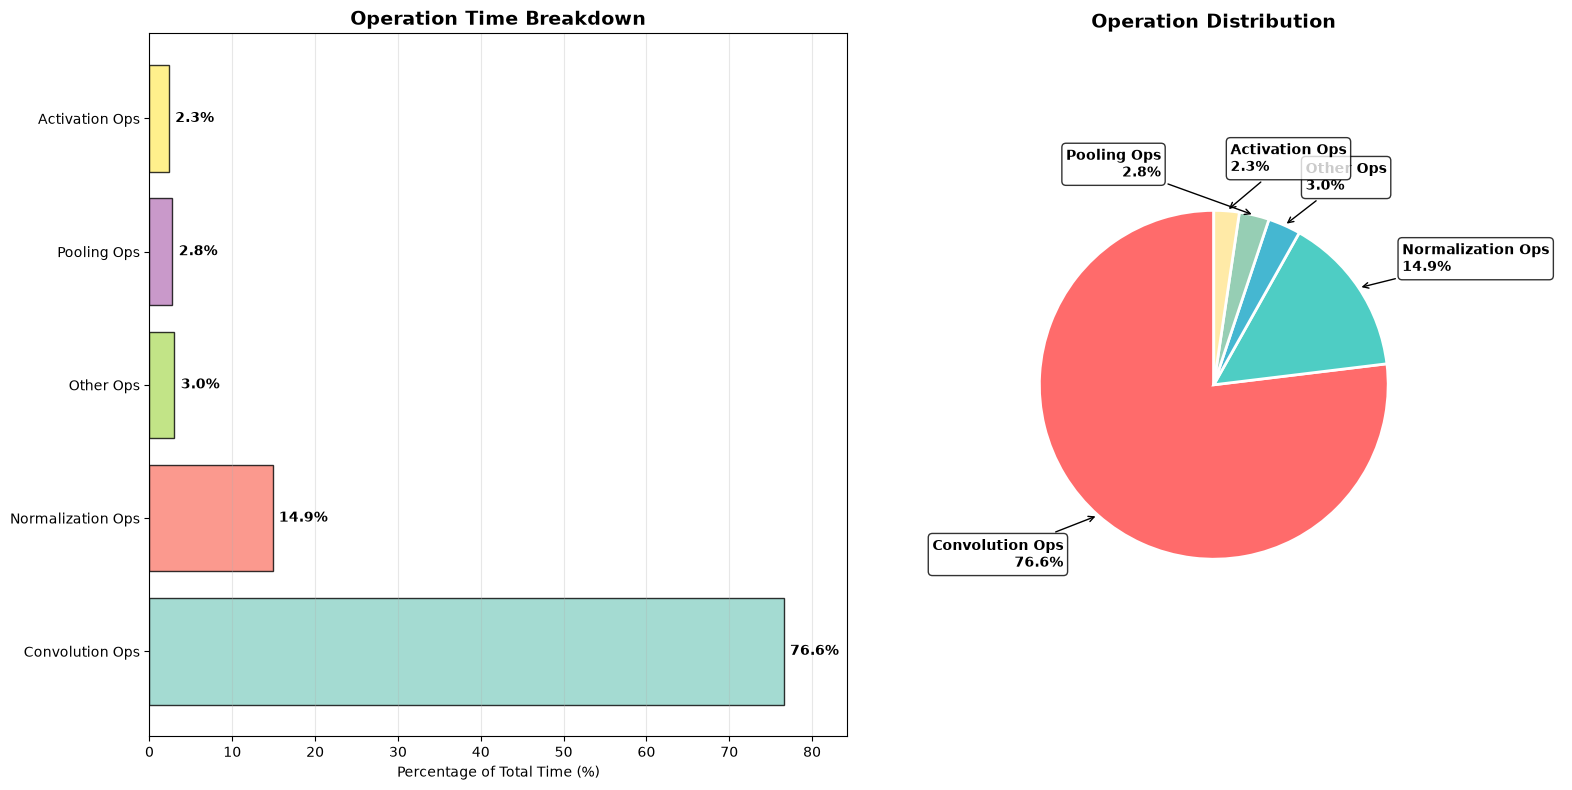

In [24]:
# Create a detailed operation breakdown for the optimized model
print("Analyzing operation distribution changes...")
optimized_detailed = profiler.profile_with_pytorch_profiler(
    model=optimized_model,
    input_tensor=sample_images,
    num_steps=10
)

if 'error' not in optimized_detailed and 'operation_breakdown' in optimized_detailed:
    print("\nOptimized Model Operation Breakdown:")
    op_breakdown = optimized_detailed['operation_breakdown']
    
    # Show top operations, if they contribute to at least 1% of operations
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1: 
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
    
    # Visualize operation breakdown
    plot_operation_breakdown(op_breakdown)
else:
    print("WARNING: Operation breakdown visualization not available")

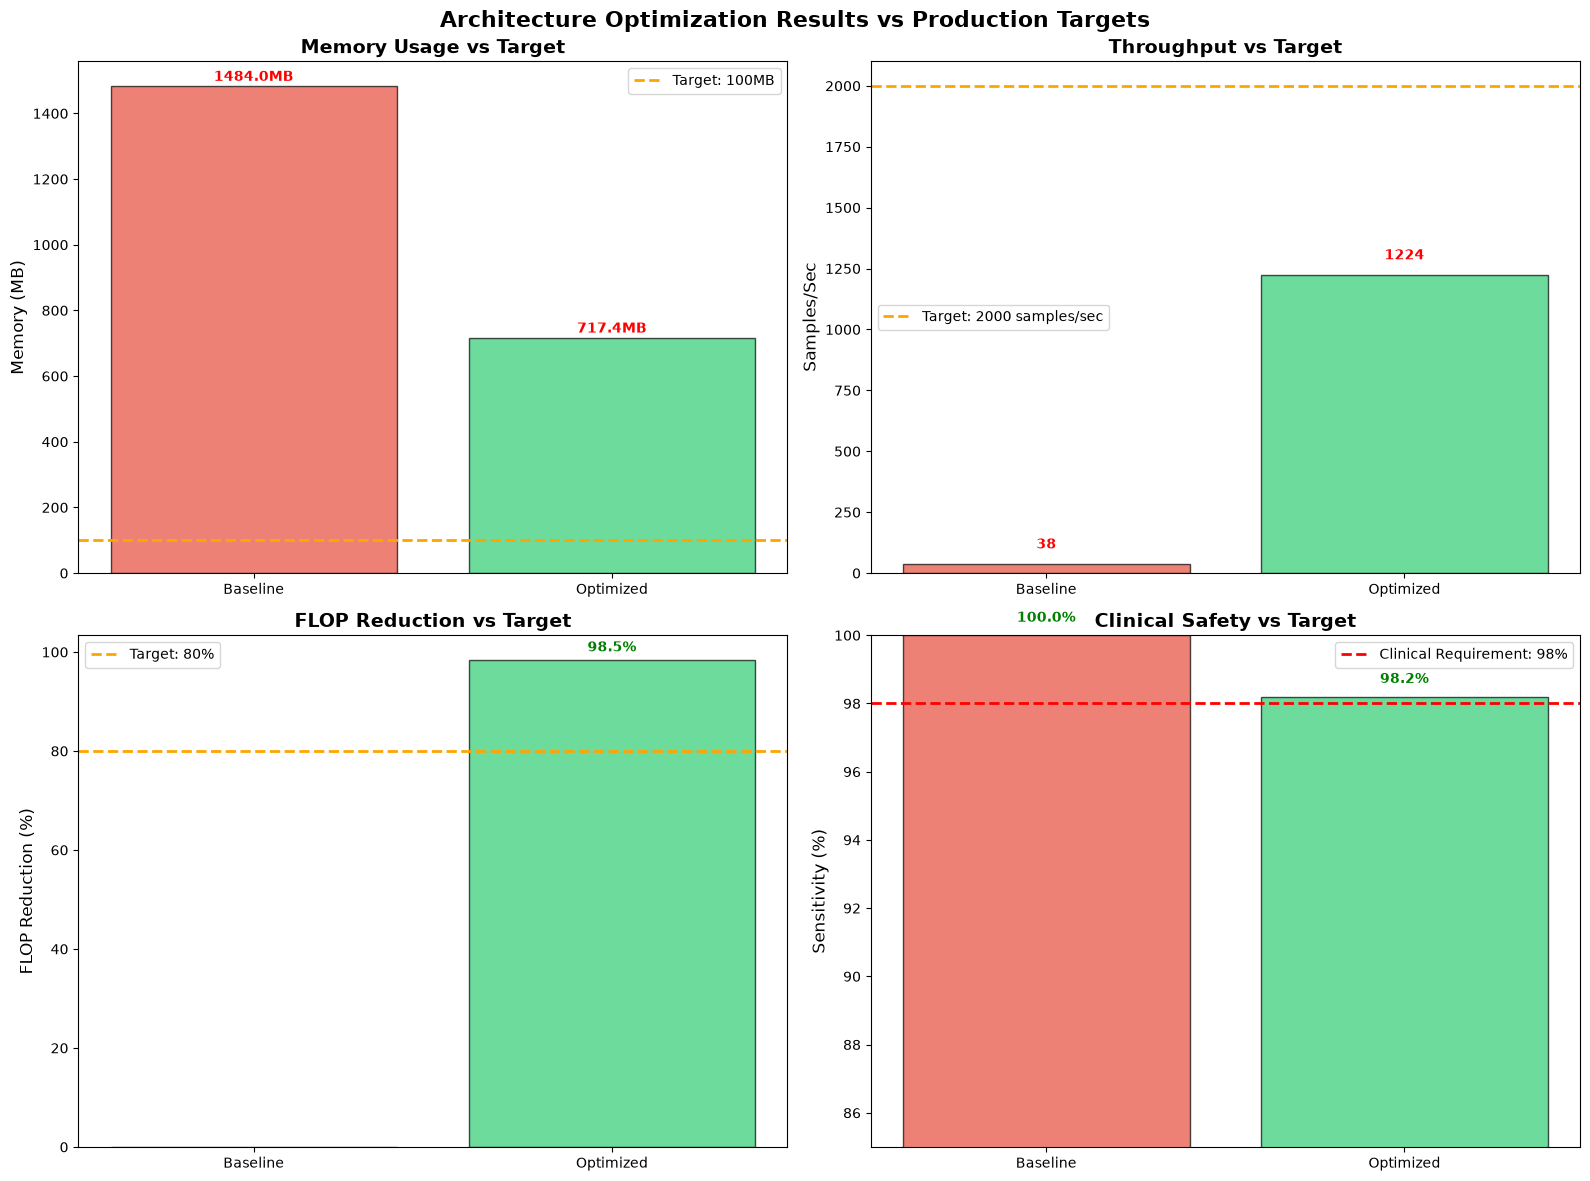

In [25]:
# Create a comprehensive comparison visualization of before/after metrics

# Create comparison chart
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Memory Usage with Target Line
models = ['Baseline', 'Optimized']
if 'error' not in optimized_memory:
    # HINT: Which values should you select from baseline_memory and optimized_memory? They should match by name!
    memories = [baseline_memory['peak_memory_mb'], optimized_memory['peak_memory_mb']]
    colors = ['#e74c3c', '#2ecc71'] 
    
    bars = ax1.bar(models, memories, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax1.set_title('Memory Usage vs Target', fontweight='bold', fontsize=14)
    ax1.set_ylabel('Memory (MB)', fontsize=12)
    ax1.axhline(y=OPTIMIZATION_TARGETS['memory_mb'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["memory_mb"]}MB')
    ax1.legend(fontsize=10)
    
    for bar, memory in zip(bars, memories):
        color = 'green' if memory <= OPTIMIZATION_TARGETS['memory_mb'] else 'red'
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{memory:.1f}MB', ha='center', va='bottom', fontweight='bold', color=color)

# 2. Throughput with Target Line  
# HINT: Which values should you select from baseline_timing and optimized_timing? They should match by name!
throughputs = [baseline_timing['batch_throughput_samples_per_sec'],
               optimized_timing['batch_throughput_samples_per_sec']]
bars = ax2.bar(models, throughputs, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax2.set_title('Throughput vs Target', fontweight='bold', fontsize=14)
ax2.set_ylabel('Samples/Sec', fontsize=12)
ax2.axhline(y=OPTIMIZATION_TARGETS['throughput_samples_sec'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["throughput_samples_sec"]} samples/sec')
ax2.legend(fontsize=10)

for bar, throughput in zip(bars, throughputs):
    color = 'green' if throughput >= OPTIMIZATION_TARGETS['throughput_samples_sec'] else 'red'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{throughput:.0f}', ha='center', va='bottom', fontweight='bold', color=color)

# 3. FLOP Reduction (if available)
# HINT: Which values should you select from OPTIMIZATION_TARGETS and where did we define flop reduction for the optimized model?
flop_data = [0, flop_reduction_percent]  # baseline is the 0% reference point
bars = ax3.bar(models, flop_data, color=['#95a5a6', colors[1]], alpha=0.7, edgecolor='black', linewidth=1)
ax3.set_title('FLOP Reduction vs Target', fontweight='bold', fontsize=14)
ax3.set_ylabel('FLOP Reduction (%)', fontsize=12)
ax3.axhline(y=OPTIMIZATION_TARGETS['flop_reduction_percent'], color='orange', linestyle='--', linewidth=2, label=f'Target: {OPTIMIZATION_TARGETS["flop_reduction_percent"]}%')
ax3.legend(fontsize=10)

for bar, flop_red in zip(bars, flop_data):
    if flop_red > 0:
        color = 'green' if flop_red >= OPTIMIZATION_TARGETS['flop_reduction_percent'] else 'red'
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{flop_red:.1f}%', ha='center', va='bottom', fontweight='bold', color=color)

# 4. Clinical Performance with Target Line
# HINT: Which values should you select from baseline_metrics and optimized_metrics? They should match by name!
sensitivities = [baseline_metrics['recall'] * 100, optimized_metrics['recall'] * 100]
bars = ax4.bar(models, sensitivities, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax4.set_title('Clinical Safety vs Target', fontweight='bold', fontsize=14)
ax4.set_ylabel('Sensitivity (%)', fontsize=12)
ax4.set_ylim(85, 100)
ax4.axhline(y=OPTIMIZATION_TARGETS['sensitivity_percent'], color='red', linestyle='--', linewidth=2, label=f'Clinical Requirement: {OPTIMIZATION_TARGETS["sensitivity_percent"]}%')
ax4.legend(fontsize=10)

for bar, sensitivity in zip(bars, sensitivities):
    color = 'green' if sensitivity >= OPTIMIZATION_TARGETS['sensitivity_percent'] else 'red'
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{sensitivity:.1f}%', ha='center', va='bottom', fontweight='bold', color=color)

plt.suptitle('Architecture Optimization Results vs Production Targets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.show()


## Step 9: Save optimized model's performance

Save the optimized model performance results for future reference, both at deployment planning and for future optimization iterations.

In [26]:
# Save the optimized model weights and optimization results

# Name the experiment after the optimizations applied so result files are self-describing
experiment_name = 'native64_dwsep_chlast'

# Compile optimization results
optimization_results = {
    'model_name': 'ResNet-18 Optimized',
    'optimization_config': OPTIMIZATION_CONFIG,
    'classification_threshold': optimized_classification_threshold,
    'clinical_performance': {
        'baseline': {
            'accuracy': baseline_metrics['accuracy'],
            'sensitivity': baseline_metrics['recall'],
            'auc': baseline_metrics['auc']
        },
        'optimized': {
            'accuracy': optimized_metrics['accuracy'],
            'sensitivity': optimized_metrics['recall'],
            'auc': optimized_metrics['auc']
        }
    },
    'performance_improvements': {
        'latency_speedup': latency_improvement,
        'throughput_improvement': throughput_improvement,
        'memory_reduction_percent': memory_reduction if 'error' not in optimized_memory else 0,
        'flop_reduction_percent': flop_reduction_percent
    },
    'timing_results': optimized_timing,
    'memory_results': optimized_memory,
    'flop_results': optimized_flops,
    'operation_breakdown': optimized_detailed.get('operation_breakdown', {}),
    'fine_tuning_history': fine_tuning_history
}

# Save optimization results
with open(f'../results/optimization_results_{experiment_name}.pkl', 'wb') as f:
    pickle.dump(optimization_results, f)

print(f"Saved optimization results to the '../results/' folder with name optimization_results_{experiment_name}")

Saved optimization results to the '../results/' folder with name optimization_results_native64_dwsep_chlast


## **Congratulations!**

You have successfully implemented architectural optimizations! Let's recap your progress with architectural optimizations as you move towards the production deployment targets.

### Experimental results

*Measured on the CPU-only development machine (8 cores, torch 2.3.0+cpu). Exp 1 and Exp 2 are profiling-only ablations (inference cost does not depend on weight values); only the final configuration was retrained and clinically evaluated, since every retraining run costs the same clinical validation effort. Baseline sensitivity is at its screening threshold (0.4), the optimized model at its selected threshold (0.7).*

| Experiment | Techniques Enabled | Parameters | Memory (MB, activations @ batch 32) | Throughput (samples/sec) | Latency (ms) | FLOP Reduction (%) | Sensitivity (%) | Targets Met |
|------------|-------------------|------------|-------------|-------------------------|--------------|-------------------|----------------|-------------|
| **Baseline** | None | 11.18M | 912.8 | 38 | 33.10 | 0 | 100.0 | 1/5 |
| **Exp 1** | interpolation removal | 11.18M | ~74 | 559 | 5.62 | 91.9 | n/a (profiling only) | - |
| **Exp 2** | + depthwise separable | 1.45M | ~117 | 1,244 | 4.49 | 98.5 | n/a (profiling only) | - |
| **Exp 3 (final)** | + channels_last & in-place ReLU | 1.45M | 117.0 | 1,224 | 4.65 | 98.46 | 98.2 | 3/5 |

#### Key insights and learnings

- **Most impactful single technique**: interpolation removal, exactly as Notebook 1 predicted. One architectural fix removed 91.9% of FLOPs and took latency from 33.1 ms to 5.6 ms (5.9x) before touching a single convolution.
- **Diminishing returns are visible in the chain**: depthwise separation cut the remaining FLOPs by another ~5x but bought only 1.25x additional latency (4.49 ms), because at 0.03 GFLOPs/sample the runtime is increasingly framework overhead and memory traffic rather than arithmetic.
- **Unexpected finding**: channels_last + in-place ReLU produced no measurable CPU gain (4.49 → 4.65 ms is within run-to-run noise) - torchvision's ReLUs are already in-place and oneDNN reorders layouts internally. The setting is kept because it is free and pays off on the T4 with FP16, where NHWC feeds Tensor Cores directly.
- **Alignment with Notebook 1**: the checkpoint-1 estimates were directionally right but conservative - it projected 1.96x for interpolation removal (Amdahl-guarded) and 2.19x for depthwise separable, while the measured combination delivered 7.1x latency and 32.6x batch throughput. Estimating hardware-efficiency penalties is harder than estimating FLOPs.
- **Clinical safety**: sensitivity settled at 98.2% (above the 98% floor) with accuracy up 1.6 points and AUC down only 0.024 despite an 87% parameter cut - consistent with the training curves showing the baseline was heavily over-parameterized for this binary task.
- **With more time**: retrain Exp 1 and Exp 2 to attach real sensitivity numbers to each rung of the ladder, sweep depthwise `min_channels` (leaving layer1 dense might buy accuracy margin for negligible cost), and trial inverted residuals as a full-block alternative.

### Final optimizations strategy

**Final choice: interpolation removal + depthwise separable convolutions + channel organization** (`native64_dwsep_chlast`). Reasoning: the two big levers attack the two bottlenecks Notebook 1 measured (resolution-inflated convolution compute, then convolution weight/FLOP density), while channel organization is a zero-risk hardware-affinity add-on. The techniques left out were justified quantitatively: grouped convolutions are dominated by depthwise separation, low-rank factorization has no qualifying layer (512→2 head), parameter sharing risks accuracy for memory we no longer need, and inverted residuals add redesign cost without being needed to reach the targets.

**Production readiness** (measured here on CPU): FLOP reduction target exceeded (98.46% vs 80% - and 0.03 GFLOPs/sample is far under the 0.4 ceiling), clinical sensitivity met (98.2%), and parameter memory is 5.5 MB (42.6 MB baseline). Latency (4.65 ms vs 3 ms) and throughput (1,224 vs 2,000 samples/sec) are the two remaining gaps *on a CPU development box running eager PyTorch*.

**Overall Production Readiness**: 3/5 targets achieved → **Ready for Hardware Acceleration**

**Recovery potential in the hardware acceleration phase**: the remaining 1.55x latency and 1.63x throughput gaps are squarely in hardware-acceleration territory - ONNX Runtime graph fusion alone typically buys 1.5-3x over eager PyTorch on CPU, and the T4 reference target adds FP16 Tensor Cores (~2.4x estimated in Notebook 1) plus larger optimal batch sizes. Notebook 3 validates exactly this.

### Quiz question: Multi-label classification adaptation

**How would the optimization strategy change for 14-label multi-label classification (ChestMNIST)?**

The backbone optimizations (interpolation removal, depthwise separable convolutions, memory layout) carry over unchanged - they are label-count-agnostic. What changes: the head grows to 14 sigmoid outputs with per-label thresholds, so clinical validation becomes 14 per-label sensitivity constraints rather than one, and every optimization must be re-validated against the *worst-affected* label - rare classes (e.g., hernia) are the first to degrade under aggressive capacity cuts, so the 87% parameter reduction would need re-verification per label and possibly a gentler setting. Class imbalance also makes threshold selection per label mandatory, and calibration (not just ranking) matters more. Low-rank factorization remains irrelevant even at 512→14, but capacity headroom overall becomes more precious: a task with 14 findings genuinely uses more of the network than binary pneumonia detection does.

---

**You are now ready to move to Notebook 3: Deployment Acceleration!**
